### Question:1

Use SDSS DR18 SQL search to find galaxies with:

- Narrow emission lines (FWHM < 500 km/s)  
- High median S/N in g band (S/N > 40)  
- Fluxes of [O III] 5007, Hβ, Hα, [N II] 6583 > 5 × 10⁻¹⁷ erg/s/cm²  
- Flux > 5 × (flux error) for all lines  

SQL output should include the fluxes of these lines.

**Optional:**  
Find class and subclass from SpecObj and compare with the BPT diagram.

The required galaxy sample was obtained using an SQL query on the SDSS database (DR18). 
Selection criteria were applied to ensure high-quality narrow emission line objects with reliable flux measurements.

### SQL Query 

```sql
SELECT
    s.specobjid,
    g.oiii_5007_flux,
    g.oiii_5007_flux_err,
    g.h_beta_flux,
    g.h_beta_flux_err,
    g.h_alpha_flux,
    g.h_alpha_flux_err,
    g.nii_6584_flux,
    g.nii_6584_flux_err
FROM SpecObjAll AS s
JOIN galSpecLine AS g
ON s.specobjid = g.specobjid
WHERE
    g.sigma_balmer < 212
    AND s.snmedian_g > 40

    AND g.oiii_5007_flux > 5e-17
    AND g.h_beta_flux > 5e-17
    AND g.h_alpha_flux > 5e-17
    AND g.nii_6584_flux > 5e-17

    AND g.oiii_5007_flux / g.oiii_5007_flux_err > 5
    AND g.h_beta_flux / g.h_beta_flux_err > 5
    AND g.h_alpha_flux / g.h_alpha_flux_err > 5
    AND g.nii_6584_flux / g.nii_6584_flux_err > 5

    AND s.class = 'GALAXY'

### Data Loading

The SQL result is saved as a CSV file and loaded into Python.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"/home/israt/Downloads/bpt_q1.csv", comment='#')


In [13]:
df.columns

Index(['specobjid', 'oiii_5007_flux', 'oiii_5007_flux_err', 'h_beta_flux',
       'h_beta_flux_err', 'h_alpha_flux', 'h_alpha_flux_err', 'nii_6584_flux',
       'nii_6584_flux_err'],
      dtype='object')

### Line Ratio Calculation

The required line ratios for the BPT diagram are computed.


In [14]:
df = df[
    (df['nii_6584_flux'] > 0) &
    (df['h_alpha_flux'] > 0) &
    (df['oiii_5007_flux'] > 0) &
    (df['h_beta_flux'] > 0) &

    (df['nii_6584_flux'] / df['nii_6584_flux_err'] > 5) &
    (df['h_alpha_flux'] / df['h_alpha_flux_err'] > 5) &
    (df['oiii_5007_flux'] / df['oiii_5007_flux_err'] > 5) &
    (df['h_beta_flux'] / df['h_beta_flux_err'] > 5)
]

df['log_NII_Ha'] = np.log10(df['nii_6584_flux'] / df['h_alpha_flux'])
df['log_OIII_Hb'] = np.log10(df['oiii_5007_flux'] / df['h_beta_flux'])

### BPT Diagram

The diagnostic BPT diagram is plotted using the line ratios.


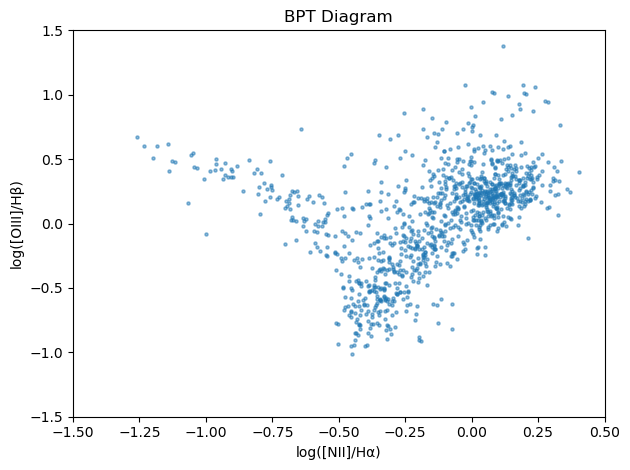

In [15]:
plt.figure()  

plt.scatter(df['log_NII_Ha'], df['log_OIII_Hb'], s=5, alpha=0.5)

plt.xlabel('log([NII]/Hα)')
plt.ylabel('log([OIII]/Hβ)')
plt.title('BPT Diagram')

plt.xlim(-1.5, 0.5)
plt.ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

### Class and Subclass 

The following SQL query is used to obtain class and subclass information from the SpecObjAll table by joining it with galSpecLine, while applying the basic selection criteria (narrow emission lines and high S/N):

```sql
SELECT
    s.class,
    s.subclass,
    g.oiii_5007_flux,
    g.h_beta_flux,
    g.h_alpha_flux,
    g.nii_6584_flux
FROM SpecObjAll AS s
JOIN galSpecLine AS g
ON s.specobjid = g.specobjid
WHERE
    g.sigma_balmer < 212
    AND s.snmedian_g > 40

In [19]:
df = pd.read_csv(r"/home/israt/Downloads/bpt_q1_op.csv", comment='#')

In [20]:
df = df.dropna(subset=['subclass'])
df[['class', 'subclass']].head()


,class,subclass
0,GALAXY,BROADLINE
1,GALAXY,AGN
2,GALAXY,STARFORMING
4,GALAXY,AGN
5,GALAXY,BROADLINE


The subclasses such as STARFORMING and BROADLINE are consistent with their expected locations in the BPT diagram. Star-forming galaxies lie in the star-forming region, while broadline objects are associated with AGN regions.

## Question 2

For the obtained sample, construct the diagnostic BPT (Baldwin, Phillips & Terlevich) diagram. This diagram is used to determine the dominant ionization source for galaxies: either AGN (accretion disk) or star-forming regions (H II regions).

For the BPT diagram, use the flux ratios:
- log([O III] 5007 / Hβ)
- log([N II] 6583 / Hα)

Optionally, draw the Schawinski (2007) line that separates LINER and Seyfert galaxies.

### Line Ratio Calculation

The emission line flux ratios required for constructing the BPT diagram are computed from the selected sample.

In [21]:
df = df[(df['nii_6584_flux'] > 0) &
        (df['h_alpha_flux'] > 0) &
        (df['oiii_5007_flux'] > 0) &
        (df['h_beta_flux'] > 0)]

df['log_NII_Ha'] = np.log10(df['nii_6584_flux'] / df['h_alpha_flux'])
df['log_OIII_Hb'] = np.log10(df['oiii_5007_flux'] / df['h_beta_flux'])

### BPT Diagram

The BPT diagram is constructed using the computed emission line ratios to classify the ionization source of galaxies.

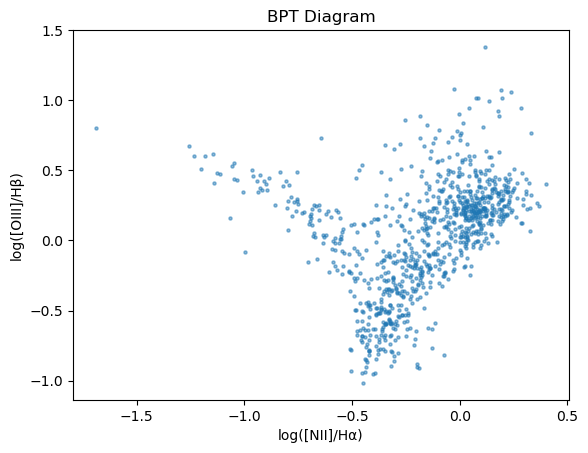

In [22]:
plt.figure()

plt.scatter(df['log_NII_Ha'], df['log_OIII_Hb'], s=5, alpha=0.5)

plt.xlabel('log([NII]/Hα)')
plt.ylabel('log([OIII]/Hβ)')
plt.title('BPT Diagram')

plt.show()

### Schawinski (2007) Separation Line 

The Schawinski (2007) line is plotted to separate LINER and Seyfert galaxies.

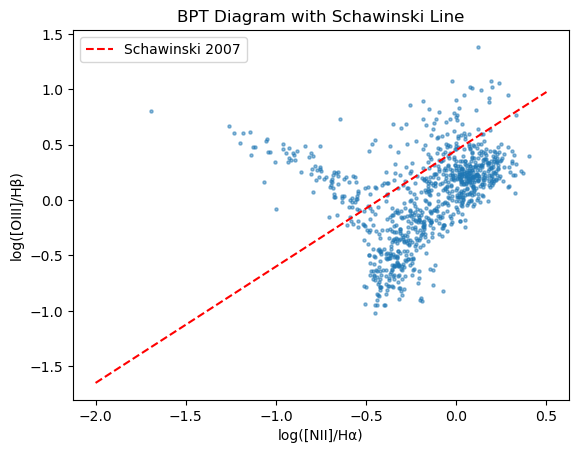

In [23]:
x = np.linspace(-2, 0.5, 100)
schawinski = 1.05 * x + 0.45

plt.figure()

plt.scatter(df['log_NII_Ha'], df['log_OIII_Hb'], s=5, alpha=0.5)
plt.plot(x, schawinski, 'r--', label='Schawinski 2007')

plt.xlabel('log([NII]/Hα)')
plt.ylabel('log([OIII]/Hβ)')
plt.title('BPT Diagram with Schawinski Line')

plt.legend()
plt.show()

## WISE Color-Color Diagram (Question 1)

For the galaxy sample selected from the SDSS DR18 database in Part I, the corresponding WISE infrared properties were obtained using cross-identification with the WISE All-Sky catalog.

The WISE magnitudes (W1, W2, W3) were retrieved by joining SDSS objects with the WISE catalog using the SkyServer SQL interface. These magnitudes were then used to compute the infrared colors (W1−W2 and W2−W3), which are commonly used to distinguish between AGN and star-forming galaxies.

### SQL Query for WISE Cross-Matching

The following SQL query was used to cross-match SDSS galaxies with the WISE catalog and retrieve the required infrared magnitudes:
```sql
SELECT TOP 1000
    s.specobjid,
    s.ra,
    s.dec,

    w.w1mpro,
    w.w2mpro,
    w.w3mpro

FROM SpecObjAll AS s

JOIN galSpecLine AS g
ON s.specobjid = g.specobjid

JOIN wise_xmatch AS x
ON s.bestobjid = x.sdss_objid

JOIN wise_allsky AS w
ON x.wise_cntr = w.cntr

WHERE
    g.sigma_balmer < 212
    AND s.snmedian_g > 40

    AND g.oiii_5007_flux > 5e-17
    AND g.h_beta_flux > 5e-17
    AND g.h_alpha_flux > 5e-17
    AND g.nii_6584_flux > 5e-17

    AND g.oiii_5007_flux / g.oiii_5007_flux_err > 5
    AND g.h_beta_flux / g.h_beta_flux_err > 5
    AND g.h_alpha_flux / g.h_alpha_flux_err > 5
    AND g.nii_6584_flux / g.nii_6584_flux_err > 5
```


In [24]:
df = pd.read_csv(r"/home/israt/Downloads/wise_q1.csv", comment="#")

### WISE Color Calculation

After downloading the SQL results as a CSV file, the data were loaded into Python for further analysis. Rows with missing WISE magnitudes were removed, and the colors were computed as:

- W1 − W2
- W2 − W3

These color indices are sensitive to dust emission and are widely used to identify AGN.

In [25]:
df = df.dropna(subset=['w1mpro','w2mpro','w3mpro'])

df['W1_W2'] = df['w1mpro'] - df['w2mpro']
df['W2_W3'] = df['w2mpro'] - df['w3mpro']

df['log_NII_Ha'] = np.log10(df['nii_6584_flux'] / df['h_alpha_flux'])
df['log_OIII_Hb'] = np.log10(df['oiii_5007_flux'] / df['h_beta_flux'])

### WISE Color-Color Diagram

The WISE color-color diagram was constructed by plotting W1−W2 versus W2−W3 for the selected galaxy sample.

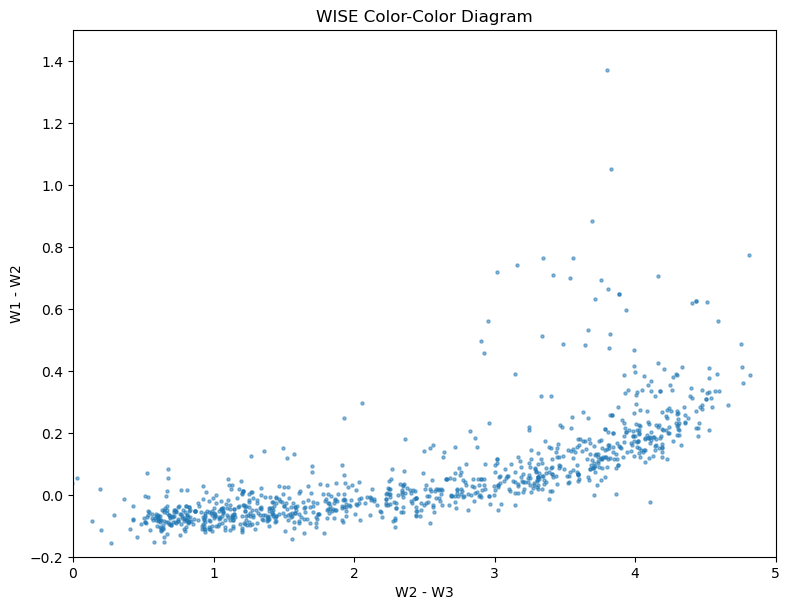

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(df['W2_W3'], df['W1_W2'], s=5, alpha=0.5)

plt.xlabel('W2 - W3')
plt.ylabel('W1 - W2')
plt.xlim(0, 5)
plt.ylim(-0.2, 1.5)
plt.tight_layout()
plt.title('WISE Color-Color Diagram')

plt.show()

### Interpretation

The WISE color–color diagram shows that most galaxies lie at low W1–W2 values, indicating star-forming systems. A smaller fraction of objects extends to higher W1–W2 values, which is characteristic of AGN due to hot dust emission in the infrared. This demonstrates that WISE colors can effectively distinguish AGN from normal galaxies.

## WISE Classification and Comparison with BPT (Question 2)

Assign classes (AGN, (u)LIRGs, spheroids, intermediate disks, and star-forming disks) to all objects using the WISE color–color diagram and the given threshold criteria.

Compare these WISE-based classifications with those obtained from the BPT diagram.

Discuss whether the classifications agree and explain any differences between the infrared (WISE) and optical (BPT) diagnostics.



The galaxy sample was classified using the WISE color–color diagram based on the infrared color indices (W1–W2 and W2–W3). Classification boundaries were applied following standard thresholds to separate AGN, (u)LIRGs, spheroids, intermediate disks, and star-forming disks.

These classifications were then compared with those obtained from the optical BPT diagram.

In [27]:
def classify_wise(row):
    if row['W1_W2'] >= 0.8:
        return 'AGN'
    elif row['W2_W3'] >= 3.5:
        return '(u)LIRG'
    elif row['W2_W3'] < 1.5:
        return 'Spheroid'
    elif 1.5 <= row['W2_W3'] < 2.5:
        return 'Intermediate Disk'
    else:
        return 'SF Disk'

df['WISE_class'] = df.apply(classify_wise, axis=1)

The WISE classifications were assigned using threshold values in the W1–W2 and W2–W3 color space.

In [28]:
df['WISE_class'].value_counts()

WISE_class
Spheroid             321
(u)LIRG              276
SF Disk              210
Intermediate Disk    190
AGN                    3
Name: count, dtype: int64

The distribution of galaxies across different WISE classes is summarized below.

In [29]:
df['log_NII_Ha'] = np.log10(df['nii_6584_flux'] / df['h_alpha_flux'])
df['log_OIII_Hb'] = np.log10(df['oiii_5007_flux'] / df['h_beta_flux'])
def classify_bpt(row):
    if row['log_OIII_Hb'] > 0.61/(row['log_NII_Ha'] - 0.05) + 1.3:
        return 'AGN'
    else:
        return 'Star-forming'

df['BPT_class'] = df.apply(classify_bpt, axis=1)

In [30]:
pd.crosstab(df['WISE_class'], df['BPT_class'])

BPT_class,AGN,Star-forming
WISE_class,,
(u)LIRG,96,180
AGN,3,0
Intermediate Disk,101,89
SF Disk,116,94
Spheroid,162,159


WISE and BPT classifications agree well for strong AGN, but show significant differences for other galaxy types. This indicates that infrared and optical methods identify different aspects of galaxy activity.

## WISE AGN Candidate Analysis (Question 3)

Locate one object in the WISE color–color diagram with W1–W2 ≥ 0.8 (Assef et al. 2013) and address the following:

- Where is the object located in this plot? Mark it clearly on the graph.
- Does it agree with the optical classification from the BPT diagram?
- Draw some conclusions about the type of AGN using the WISE color–color plot.

An object with W1–W2 ≥ 0.8 was selected from the WISE color–color diagram and marked on the plot for analysis.

In [31]:
agn_candidate = df[df['W1_W2'] >= 0.8].iloc[0]
agn_candidate

specobjid             1999772022116214784
ra                              206.70605
dec                             14.400467
w1mpro                             10.197
w2mpro                              9.315
w3mpro                              5.619
oiii_5007_flux                   4133.134
oiii_5007_flux_err               31.57422
h_beta_flux                      3754.218
h_beta_flux_err                  28.37833
h_alpha_flux                     16633.67
h_alpha_flux_err                 98.18549
nii_6584_flux                    6907.328
nii_6584_flux_err                39.56104
W1_W2                               0.882
W2_W3                               3.696
log_NII_Ha                      -0.381678
log_OIII_Hb                       0.04176
WISE_class                            AGN
BPT_class                             AGN
Name: 223, dtype: object

The selected object is highlighted on the WISE color–color diagram using a red mark.

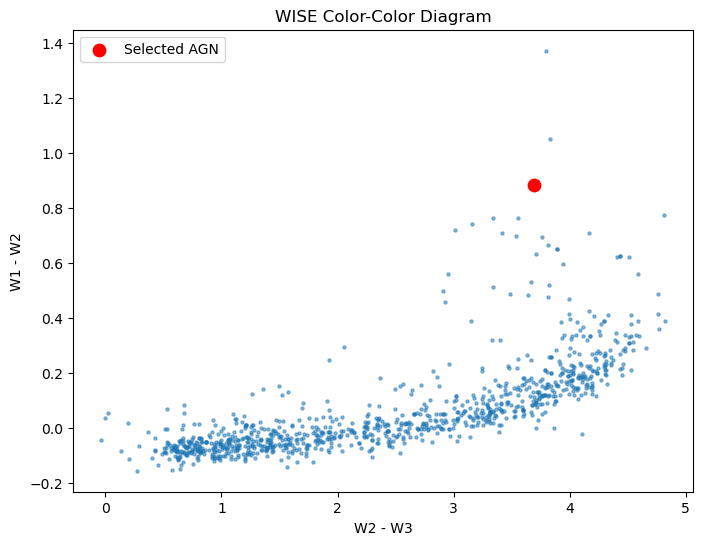

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(df['W2_W3'], df['W1_W2'], s=5, alpha=0.5)

plt.scatter(agn_candidate['W2_W3'], agn_candidate['W1_W2'],
            color='red', s=80, label='Selected AGN')

plt.xlabel('W2 - W3')
plt.ylabel('W1 - W2')
plt.title('WISE Color-Color Diagram')

plt.legend()
plt.show()

### Location of the Object

The selected object is located at:

- W1–W2 = 0.88  
- W2–W3 = 3.70  

This position lies in the AGN region of the WISE color–color diagram.

In [33]:
print("W1-W2 =", agn_candidate['W1_W2'])
print("W2-W3 =", agn_candidate['W2_W3'])
print("WISE class =", agn_candidate['WISE_class'])
print("BPT class =", agn_candidate['BPT_class'])

W1-W2 = 0.8819999999999997
W2-W3 = 3.6959999999999997
WISE class = AGN
BPT class = AGN


Both WISE and BPT classifications identify this object as an AGN, indicating strong agreement between infrared and optical diagnostics.

This suggests that the object is a robust AGN candidate, clearly detected in both wavelength regimes.